# Crop Disease Detection — EDA
Exploring the PlantVillage dataset before training.

In [9]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [10]:

DATA_DIR = Path("data\PlantVillage")
SEED = 42
random.seed(SEED)
print("Data folder exists:", DATA_DIR.exists())

Data folder exists: True


In [11]:
class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])

image_counts = {}
for d in class_dirs:
    imgs = list(d.glob("*.jpg")) + list(d.glob("*.JPG")) + list(d.glob("*.png"))
    if imgs:
        image_counts[d.name] = len(imgs)

class_names = list(image_counts.keys())
total = sum(image_counts.values())

print(f"Classes : {len(class_names)}")
print(f"Images  : {total:,}")
print(f"Avg per class: {total // len(class_names)}")


Classes : 15
Images  : 41,273
Avg per class: 2751


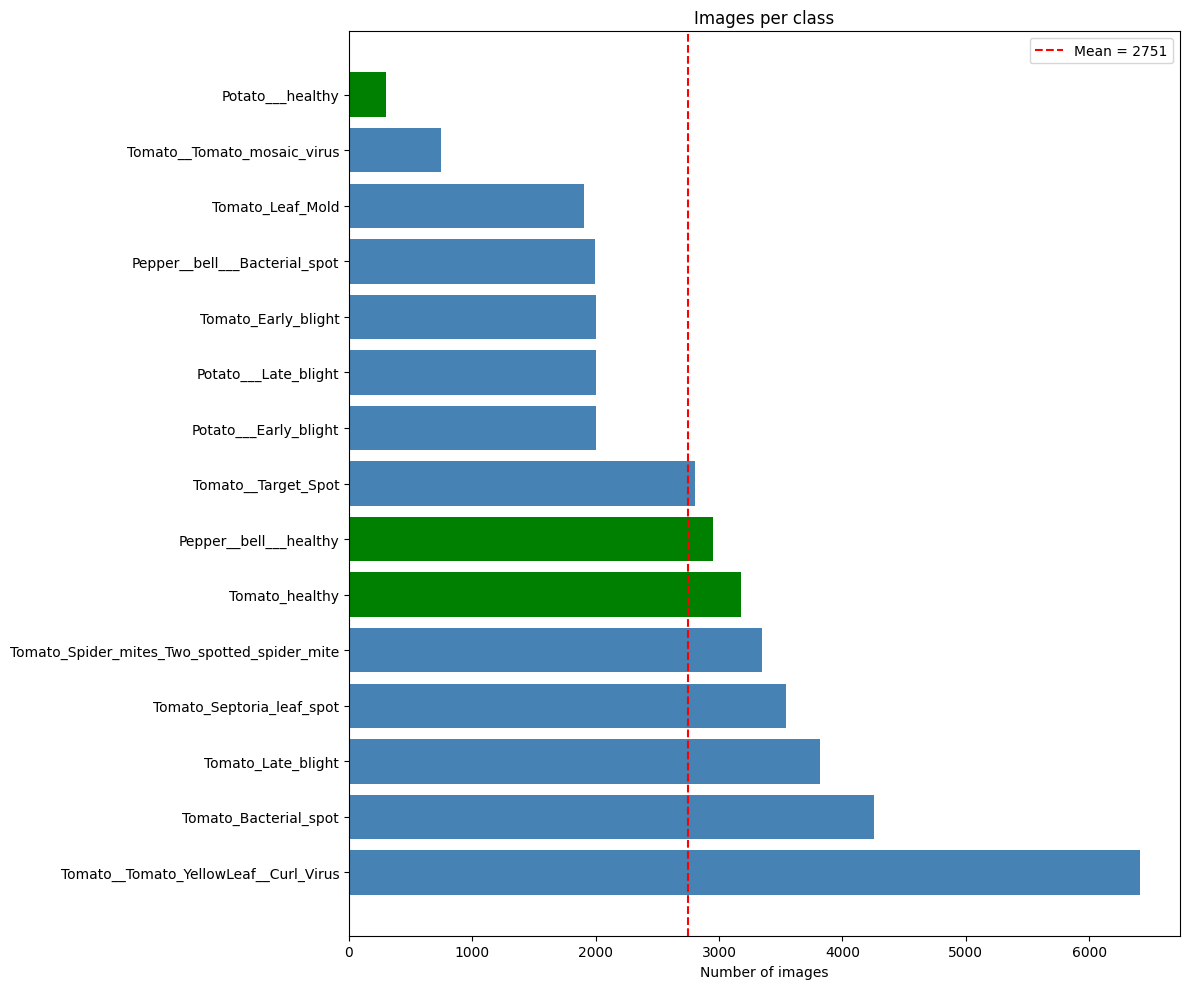

Min: 304 | Max: 6416 | Ratio: 21.1x


In [12]:
sorted_items = sorted(image_counts.items(), key=lambda x: x[1], reverse=True)
names  = [x[0] for x in sorted_items]
counts = [x[1] for x in sorted_items]
colors = ["green" if "healthy" in n.lower() else "steelblue" for n in names]

plt.figure(figsize=(12, 10))
plt.barh(names, counts, color=colors)
plt.axvline(np.mean(counts), color="red", linestyle="--", label=f"Mean = {int(np.mean(counts))}")
plt.xlabel("Number of images")
plt.title("Images per class")
plt.legend()
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

print(f"Min: {min(counts)} | Max: {max(counts)} | Ratio: {max(counts)/min(counts):.1f}x")


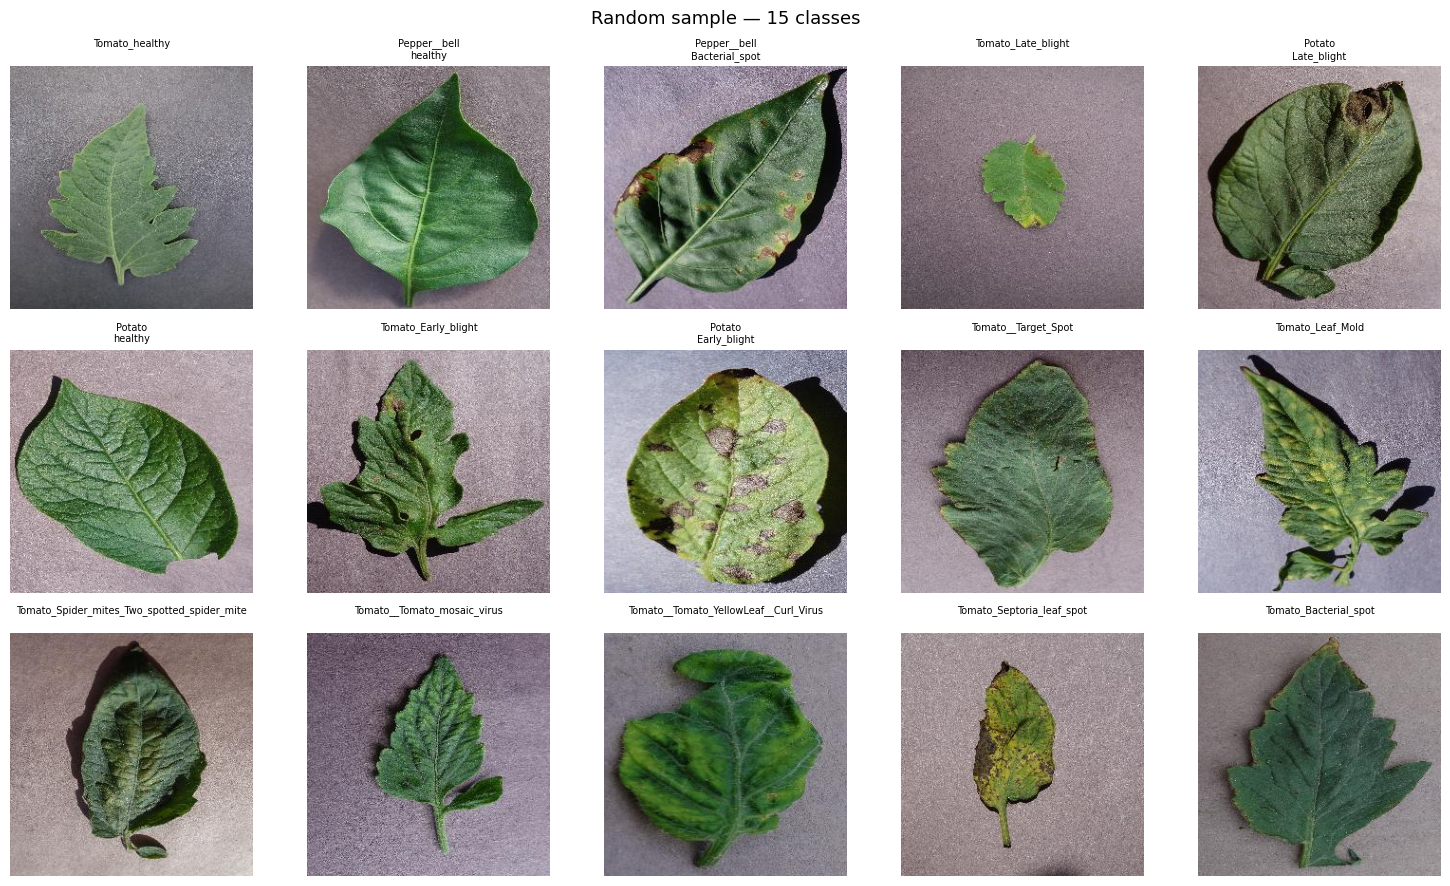

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

sampled_classes = random.sample(class_names, 15)

for ax, cls in zip(axes, sampled_classes):
    img_paths = list((DATA_DIR / cls).glob("*.jpg")) + list((DATA_DIR / cls).glob("*.JPG"))
    img = Image.open(random.choice(img_paths)).convert("RGB")
    ax.imshow(img)
    # just show crop and disease on two lines
    parts = cls.split("___")
    ax.set_title(f"{parts[0]}\n{parts[1] if len(parts)>1 else ''}", fontsize=7)
    ax.axis("off")

plt.suptitle("Random sample — 15 classes", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()


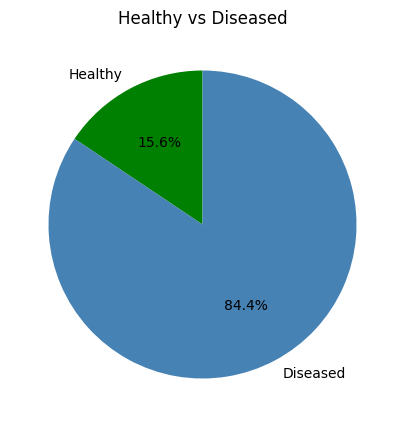

Healthy : 6,441
Diseased: 34,832


In [14]:
healthy  = sum(v for k, v in image_counts.items() if "healthy" in k.lower())
diseased = sum(v for k, v in image_counts.items() if "healthy" not in k.lower())

plt.figure(figsize=(5, 5))
plt.pie(
    [healthy, diseased],
    labels=["Healthy", "Diseased"],
    autopct="%1.1f%%",
    colors=["green", "steelblue"],
    startangle=90
)
plt.title("Healthy vs Diseased")
plt.savefig("healthy_diseased_split.png")
plt.show()

print(f"Healthy : {healthy:,}")
print(f"Diseased: {diseased:,}")


In [15]:
all_paths = []
for cls in class_names:
    paths = list((DATA_DIR / cls).glob("*.jpg")) + list((DATA_DIR / cls).glob("*.JPG"))
    all_paths.extend(paths)

sample = random.sample(all_paths, min(200, len(all_paths)))

widths, heights = [], []
for p in sample:
    w, h = Image.open(p).size
    widths.append(w)
    heights.append(h)

print(f"Width  — min: {min(widths)} | max: {max(widths)} | mean: {int(np.mean(widths))}")
print(f"Height — min: {min(heights)} | max: {max(heights)} | mean: {int(np.mean(heights))}")
print()
print("Most images are 256x256 — we will resize to 224x224 for EfficientNet")


Width  — min: 256 | max: 256 | mean: 256
Height — min: 256 | max: 256 | mean: 256

Most images are 256x256 — we will resize to 224x224 for EfficientNet


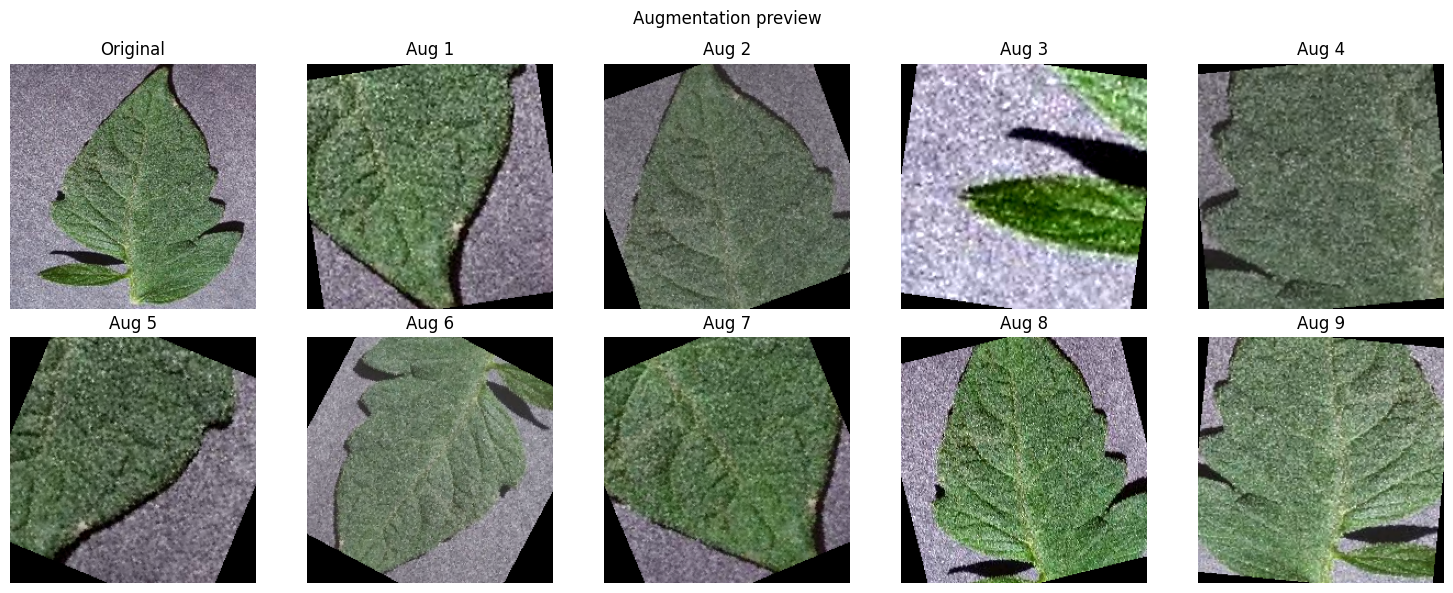

In [16]:
from torchvision import transforms

aug = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(30),
])

sample_path = random.choice(all_paths)
original = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

axes[0].imshow(original.resize((224, 224)))
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 10):
    axes[i].imshow(aug(original))
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

plt.suptitle("Augmentation preview", fontsize=12)
plt.tight_layout()
plt.savefig("augmentation_preview.png")
plt.show()
